In [1]:
import os
import math
from tqdm.auto import tqdm
import matplotlib.pyplot as plt 

import numpy as np 
from PIL import Image
import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchinfo import summary
from sklearn.model_selection import train_test_split

In [2]:
seed = 42
data_path = '../data/raw/dataset_CIDIS_sisr_x8/thermal'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 64
lr = 1e-5
in_channels = 3
out_channels = 3
num_features = 64
num_blocks = 16
res_scale = 0.1
epochs = 50
max_count = 5
best_model_path = '../model/EDSR.pth'

In [3]:
def set_seed(seed=42):
    # np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

In [4]:
train_path_LR = os.path.join(data_path, 'train', 'LR_x8')
train_path_GT = os.path.join(data_path, 'train', 'GT')
print(train_path_LR)
print(train_path_GT)

../data/raw/dataset_CIDIS_sisr_x8/thermal\train\LR_x8
../data/raw/dataset_CIDIS_sisr_x8/thermal\train\GT


In [5]:
val_path_LR = os.path.join(data_path, 'val', 'LR_x8')
val_path_GT = os.path.join(data_path, 'val', 'GT')
print(val_path_LR)
print(val_path_GT)

../data/raw/dataset_CIDIS_sisr_x8/thermal\val\LR_x8
../data/raw/dataset_CIDIS_sisr_x8/thermal\val\GT


In [6]:
test_path = os.path.join(data_path, 'test', 'sisr_x8', 'LR_x8')
print(test_path)

../data/raw/dataset_CIDIS_sisr_x8/thermal\test\sisr_x8\LR_x8


In [7]:
class CIDISDataset(Dataset):
    def __init__(self, data_path, transforms=None, split='train'):
        self.split = split
        self.transforms = transforms
        if split != 'test':
            self.LR_dir = os.path.join(data_path, split, 'LR_x8')
            self.GT_dir = os.path.join(data_path, split, 'GT')

            self.LR_images = sorted(os.listdir(self.LR_dir))
            self.GT_images = sorted(os.listdir(self.GT_dir))
        else: 
            self.LR_dir = os.path.join(data_path, split, 'sisr_x8', 'LR_x8')
            self.LR_images = os.listdir(self.LR_dir)

    def __len__(self):
        return len(self.LR_images)

    def __getitem__(self, idx):

        LR_image_path = os.path.join(self.LR_dir, self.LR_images[idx])
        LR_image = Image.open(LR_image_path).convert('RGB')
        LR_image = np.array(LR_image)
        if self.split == 'test':
            return LR_image
        
        GT_image_path = os.path.join(self.GT_dir, self.GT_images[idx])
        GT_image = Image.open(GT_image_path).convert('RGB')
        GT_image = np.array(GT_image)

        if self.transforms:
            transform_image = self.transforms(image=LR_image, GT_image=GT_image)
            LR_image = transform_image['image']
            GT_image = transform_image['GT_image']

        return LR_image, GT_image    


In [8]:
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
], additional_targets={'GT_image': 'image'}, is_check_shapes=False)

val_test_transforms = A.Compose([
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
], additional_targets={'GT_image': 'image'}, is_check_shapes=False)

In [9]:
train_dataset = CIDISDataset(data_path, transforms=train_transforms, split='train')
val_dataset = CIDISDataset(data_path, transforms=val_test_transforms, split='val')
test_dataset = CIDISDataset(data_path, transforms=val_test_transforms, split='test')

In [10]:
LR_IMG, GT_IMG = train_dataset[0]
print(LR_IMG.shape, GT_IMG.shape)

torch.Size([3, 56, 80]) torch.Size([3, 448, 640])


In [11]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

torch.Size([64, 3, 56, 80]) torch.Size([64, 3, 448, 640])


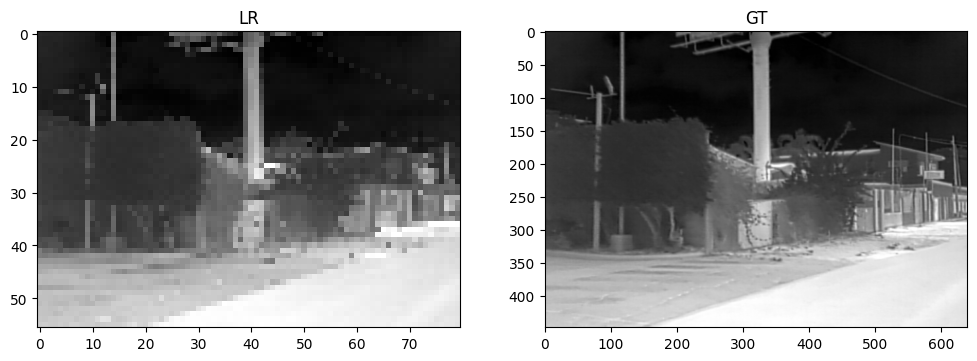

In [12]:
lr_img, gt_img = next(iter(train_loader))
print(lr_img.shape, gt_img.shape)

# Hiển thị 1 cặp ảnh đầu tiên trong batch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(lr_img[0].permute(1, 2, 0))  # Lấy ảnh đầu tiên, CHW -> HWC
axes[0].set_title('LR')
axes[1].imshow(gt_img[0].permute(1, 2, 0))
axes[1].set_title('GT')
plt.show()


## pipeline model 1: EDSR



In [13]:
class ChannelAttention(nn.Module):
    def __init__(self, num_features, reduction=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Sequential(
            nn.Conv2d(num_features, num_features // reduction, kernel_size=1, padding=0, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features // reduction, num_features, kernel_size=1, padding=0, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        y = self.avg(x) 
        y = self.conv(y)
        return x * y
        

In [14]:
class ResBlock(nn.Module):
    def __init__(self, num_features, res_scale=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)
        self.ChannelAttention = ChannelAttention(num_features, reduction=16)
        self.relu = nn.ReLU()
        self.res_scale = res_scale
    
    def forward(self, x):
        residual = x
        out = self.relu(self.conv1(x))
        out = self.conv2(x)
        out = self.ChannelAttention(out) + self.res_scale + residual
        return out

In [15]:
class Upsampler(nn.Module):
    """Upsample for x8 SR"""
    def __init__(self, in_channels, scale_factor=8):
        super().__init__()
        self.upsampler = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, in_channels * 4, kernel_size=3, padding=1),
                nn.PixelShuffle(2),
                nn.ReLU(inplace=True)
            ) for _ in range(int(math.log2(scale_factor)))
        ])
    
    def forward(self, x):
        for block in self.upsampler:
            x = block(x)
        return x

In [16]:
class EDSR(nn.Module):
    def __init__(self, in_channels, out_channels, num_features, num_blocks, res_scale=0.1):
        super().__init__()

        out_channels = out_channels if out_channels is not None else in_channels

        # Head
        self.head = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)

        # Body (Stack ResBlock)
        self.StackResBlock = nn.ModuleList([
            ResBlock(num_features, res_scale=res_scale) for _ in range(num_blocks)
        ])

        # Upsampler 
        self.upsampler = Upsampler(num_features, scale_factor=8)

        # Additional upsampling conv for fine adjustment
        self.upsample_conv = nn.Conv2d(num_features, num_features, kernel_size=3, padding=1)

        # Tail
        self.tail = nn.Conv2d(num_features, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.head(x)
        residual = x
        for block in self.StackResBlock:
            x = block(x)
        x = x + residual
        x = self.upsampler(x)
        x = self.upsample_conv(x)
        x = self.tail(x)
        return x

In [17]:
model = EDSR(in_channels, out_channels, num_features, num_blocks, res_scale).to(device)
summary(model)

Layer (type:depth-idx)                        Param #
EDSR                                          --
├─Conv2d: 1-1                                 1,792
├─ModuleList: 1-2                             --
│    └─ResBlock: 2-1                          --
│    │    └─Conv2d: 3-1                       36,928
│    │    └─Conv2d: 3-2                       36,928
│    │    └─ChannelAttention: 3-3             580
│    │    └─ReLU: 3-4                         --
│    └─ResBlock: 2-2                          --
│    │    └─Conv2d: 3-5                       36,928
│    │    └─Conv2d: 3-6                       36,928
│    │    └─ChannelAttention: 3-7             580
│    │    └─ReLU: 3-8                         --
│    └─ResBlock: 2-3                          --
│    │    └─Conv2d: 3-9                       36,928
│    │    └─Conv2d: 3-10                      36,928
│    │    └─ChannelAttention: 3-11            580
│    │    └─ReLU: 3-12                        --
│    └─ResBlock: 2-4              

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.L1Loss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    min_lr=1e-6
)

In [19]:
def train(model, optimizer, scheduler, criterion, train_loader, val_loader, epochs, max_count, best_model_path, device='cpu'):

    train_loss = []
    val_loss = []
    best_val_loss = 100000
    max_count = max_count
    break_count = 0

    for epoch in tqdm(range(epochs), desc='Current epoch/Total epoch', position=0):

        train_epoch_loss = 0
        train_total_count = 0
        val_epoch_loss = 0
        val_total_count = 0
        
        # Training parse
        model.train()
        for LR_image, GT_image in tqdm(train_loader, desc='Training batch', position=1, leave=False):
            LR_image = LR_image.to(device)
            GT_image = GT_image.to(device)

            optimizer.zero_grad()

            predictions = model(LR_image)

            loss = criterion(predictions, GT_image)
            train_epoch_loss += loss.item()

            loss.backward()
            optimizer.step()

        train_loss.append(train_epoch_loss / len(train_loader))

        # Eval parse
        model.eval()
        with torch.no_grad():
            for LR_image, GT_image in tqdm(val_loader, desc='Valid batch', position=1, leave=False):
                LR_image = LR_image.to(device)
                GT_image = GT_image.to(device)

                predictions = model(LR_image)

                loss = criterion(predictions, GT_image)
                val_epoch_loss += loss.item()

        val_loss.append(val_epoch_loss / len(val_loader))

        scheduler.step(val_loss[-1])

        if val_loss[-1] < best_val_loss:
            break_count = 0
            best_val_loss = val_loss[-1]
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': val_loss[-1],
            }, best_model_path)
        else:
            break_count += 1
        
        if break_count >= max_count:
            print(f'Break at Epoch: {epoch} with best validation loss: {val_loss[-1]}')
            break

        if epoch % log_interval == 0:
            print(f'| Epoch {epoch} |  Train Loss {train_loss[-1]} | Val Loss {val_loss[-1]} |')

    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print('Training complete and load best model')
    metrics = {
        'train_loss': train_loss,
        'val_loss': val_loss
    }
    return model, metrics

In [20]:
train(model, 
      optimizer, 
      scheduler, 
      criterion, 
      train_loader, 
      val_loader, 
      epochs, 
      max_count, 
      best_model_path, 
      device)

Current epoch/Total epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Training batch:   0%|          | 0/11 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 4.38 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 3.84 GiB is allocated by PyTorch, and 885.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)